In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
df=pd.read_csv("The_Cancer_data_1500_V2 (1).csv")
df.head()


,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


In [53]:
df.tail()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
1495,62,1,25.090025,0,0,9.892167,1.284158,0,1
1496,31,0,33.447125,0,1,1.668297,2.280636,1,1
1497,63,1,32.613861,1,1,0.466848,0.150101,0,1
1498,55,0,25.568216,0,0,7.795317,1.986138,1,1
1499,67,1,23.663104,0,0,2.525860,2.856600,1,0


In [54]:
df.shape

(1500, 9)

In [55]:
df.isna().sum()

Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   int64  
 1   Gender            1500 non-null   int64  
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   int64  
 4   GeneticRisk       1500 non-null   int64  
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   int64  
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.6 KB


In [57]:
df.drop('Diagnosis',axis=1,inplace=True)

In [58]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity',
       'AlcoholIntake', 'CancerHistory'],
      dtype='str')

In [59]:
df.fillna(df['Age'].mean(),axis=1,inplace=True)

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory
0,58.0,1.0,16.085313,0.0,1.0,8.146251,4.148219,1.0
1,71.0,0.0,30.828784,0.0,1.0,9.361630,3.519683,0.0
2,48.0,1.0,38.785084,0.0,2.0,5.135179,4.728368,0.0
3,34.0,0.0,30.040296,0.0,0.0,9.502792,2.044636,0.0
4,62.0,1.0,35.479721,0.0,0.0,5.356890,3.309849,0.0
...,...,...,...,...,...,...,...,...
1495,62.0,1.0,25.090025,0.0,0.0,9.892167,1.284158,0.0
1496,31.0,0.0,33.447125,0.0,1.0,1.668297,2.280636,1.0
1497,63.0,1.0,32.613861,1.0,1.0,0.466848,0.150101,0.0
1498,55.0,0.0,25.568216,0.0,0.0,7.795317,1.986138,1.0


In [61]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1495    False
1496    False
1497    False
1498    False
1499    False
Length: 1500, dtype: bool

In [64]:
df1=df.drop_duplicates()

In [66]:
df1.shape

(1500, 8)

In [67]:
# Separate people by age group and summarize CancerHistory
df_age_grouped = df1.copy()
df_age_grouped['AgeGroup'] = df_age_grouped['Age'].apply(
    lambda x: 'Age < 40' if x < 40 else ('Age > 40' if x > 40 else 'Age = 40')
)

# Count of cancer history (0 = No, 1 = Yes) in each age group
age_cancer_summary = (
    df_age_grouped.groupby(['AgeGroup', 'CancerHistory'])
    .size()
    .unstack(fill_value=0)
    .rename(index={0: 'No Cancer History', 1: 'Has Cancer History'})
)

print(age_cancer_summary)

CancerHistory  0.0  1.0
AgeGroup               
Age < 40       397   67
Age = 40        15    5
Age > 40       872  144


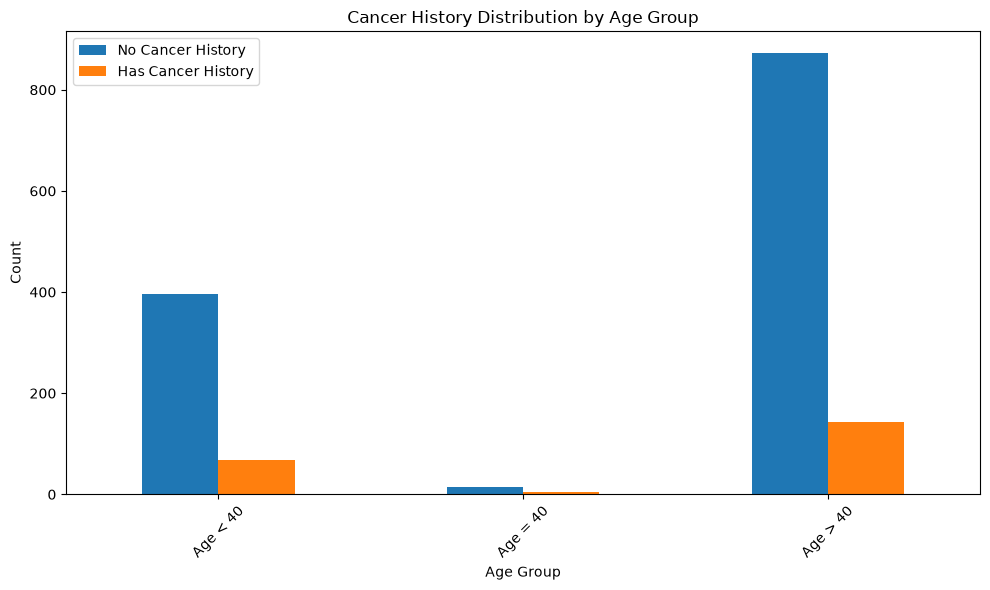

In [70]:
# Create a bar plot from age_cancer_summary
age_cancer_summary.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Cancer History Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(['No Cancer History', 'Has Cancer History'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Create a pie chart from age_cancer_summary
age_cancer_summary.plot(kind='pie', figsize=(12, 5), subplots=True)
plt.title('Cancer History Distribution by Age Group')
plt.ylabel('')
plt.tight_layout()
plt.show()